# Tufa Labs ARC3 submission

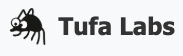

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
os.environ["B122_BOOT_ONLY"] = "1"  # boot canary: measure the serve path, SKIP the game window
print(
    "B122-CANARY mode=boot-only "
    "brain=ippeiogawa/qwen35-122b-a10b-nvfp4 (Qwen3.5-122B-A10B NVFP4, 10B active) "
    "wheels=jcole75/arc3-qwen36-runtime-wheels (vLLM 0.24.0 / modelopt 0.45.0 / CUDA 13.3) "
    "base=frozen duckfork (17 cells, code-identical to the 1.62 kernel) "
    "measurement=decode throughput ONLY; k=1 => NO capability reading "
    "(learnings/a17_error_model.md: k=1 false-NO-GO = 1.0)",
    flush=True,
)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
# B122-CANARY: the duck's pinned wheelhouse (vLLM 0.19.0, H100 build, NO ModelOpt) cannot
# load an NVFP4/ModelOpt checkpoint. Swapped for jcole75's SM120 build. The 27B is NOT
# attached: the three files we need from it are embedded in the setup command (~10 KB).
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "jcole75/arc3-qwen36-runtime-wheels", "ippeiogawa/qwen35-122b-a10b-nvfp4"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# --- B122-CANARY BEGIN serve-config rewrite (loud-fail; no fallback brain) ---
# POLICY INVERSION, as in the a17 canary: eval grafts normally fall back to vanilla
# duck on failure. Here a vanilla run would SILENTLY SERVE THE 27B and report the
# INCUMBENT's throughput as the 122B's, so ANY rewrite failure raises -> kernel ERROR.
B122_SETUP_REWRITES = [("WHEELHOUSE_OWNER = 'driessmit1'", "WHEELHOUSE_OWNER = 'jcole75'"), ("WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'", "WHEELHOUSE_SLUG = 'arc3-qwen36-runtime-wheels'"), ("MODEL_OWNER = 'driessmit1'", "MODEL_OWNER = 'ippeiogawa'"), ("MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'", "MODEL_SLUG = 'qwen35-122b-a10b-nvfp4'"), ("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'", "SERVED_MODEL_NAME = 'Qwen/Qwen3.5-122B-A10B'"), ('VLLM_MAX_MODEL_LEN = 65536', 'VLLM_MAX_MODEL_LEN = 32768'), ("STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\\n'", "STAMP_TEXT = 'vllm==0.24.0 transformers==5.13.0 nvidia-modelopt==0.45.0 cuda13.3\\n'"), ("    requirements = WHEELHOUSE / 'requirements.lock'", "    requirements = WHEELHOUSE / 'requirements-runtime.txt'\n    # B122-CANARY: jcole75's layout is a wheels/ subdir plus a runtime requirements\n    # file, not a lock file at the wheelhouse root (the duck wheelhouse's layout)."), ("        '--find-links',\n        str(WHEELHOUSE),\n", "        '--find-links',\n        str(WHEELHOUSE / 'wheels'),\n"), ('MODEL_PATH = resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)', '_B122_SHIM_FILES = json.loads(r\'\'\'{"chat_template.jinja": "eyUtIHNldCBpbWFnZV9jb3VudCA9IG5hbWVzcGFjZSh2YWx1ZT0wKSAlfQp7JS0gc2V0IHZpZGVvX2NvdW50ID0gbmFtZXNwYWNlKHZhbHVlPTApICV9CnslLSBtYWNybyByZW5kZXJfY29udGVudChjb250ZW50LCBkb192aXNpb25fY291bnQsIGlzX3N5c3RlbV9jb250ZW50PWZhbHNlKSAlfQogICAgeyUtIGlmIGNvbnRlbnQgaXMgc3RyaW5nICV9CiAgICAgICAge3stIGNvbnRlbnQgfX0KICAgIHslLSBlbGlmIGNvbnRlbnQgaXMgaXRlcmFibGUgYW5kIGNvbnRlbnQgaXMgbm90IG1hcHBpbmcgJX0KICAgICAgICB7JS0gZm9yIGl0ZW0gaW4gY29udGVudCAlfQogICAgICAgICAgICB7JS0gaWYgJ2ltYWdlJyBpbiBpdGVtIG9yICdpbWFnZV91cmwnIGluIGl0ZW0gb3IgaXRlbS50eXBlID09ICdpbWFnZScgJX0KICAgICAgICAgICAgICAgIHslLSBpZiBpc19zeXN0ZW1fY29udGVudCAlfQogICAgICAgICAgICAgICAgICAgIHt7LSByYWlzZV9leGNlcHRpb24oJ1N5c3RlbSBtZXNzYWdlIGNhbm5vdCBjb250YWluIGltYWdlcy4nKSB9fQogICAgICAgICAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgZG9fdmlzaW9uX2NvdW50ICV9CiAgICAgICAgICAgICAgICAgICAgeyUtIHNldCBpbWFnZV9jb3VudC52YWx1ZSA9IGltYWdlX2NvdW50LnZhbHVlICsgMSAlfQogICAgICAgICAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgYWRkX3Zpc2lvbl9pZCAlfQogICAgICAgICAgICAgICAgICAgIHt7LSAnUGljdHVyZSAnIH4gaW1hZ2VfY291bnQudmFsdWUgfiAnOiAnIH19CiAgICAgICAgICAgICAgICB7JS0gZW5kaWYgJX0KICAgICAgICAgICAgICAgIHt7LSAnPHx2aXNpb25fc3RhcnR8Pjx8aW1hZ2VfcGFkfD48fHZpc2lvbl9lbmR8PicgfX0KICAgICAgICAgICAgeyUtIGVsaWYgJ3ZpZGVvJyBpbiBpdGVtIG9yIGl0ZW0udHlwZSA9PSAndmlkZW8nICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgaXNfc3lzdGVtX2NvbnRlbnQgJX0KICAgICAgICAgICAgICAgICAgICB7ey0gcmFpc2VfZXhjZXB0aW9uKCdTeXN0ZW0gbWVzc2FnZSBjYW5ub3QgY29udGFpbiB2aWRlb3MuJykgfX0KICAgICAgICAgICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgICAgICAgICAgeyUtIGlmIGRvX3Zpc2lvbl9jb3VudCAlfQogICAgICAgICAgICAgICAgICAgIHslLSBzZXQgdmlkZW9fY291bnQudmFsdWUgPSB2aWRlb19jb3VudC52YWx1ZSArIDEgJX0KICAgICAgICAgICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgICAgICAgICAgeyUtIGlmIGFkZF92aXNpb25faWQgJX0KICAgICAgICAgICAgICAgICAgICB7ey0gJ1ZpZGVvICcgfiB2aWRlb19jb3VudC52YWx1ZSB+ICc6ICcgfX0KICAgICAgICAgICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgICAgICAgICAge3stICc8fHZpc2lvbl9zdGFydHw+PHx2aWRlb19wYWR8Pjx8dmlzaW9uX2VuZHw+JyB9fQogICAgICAgICAgICB7JS0gZWxpZiAndGV4dCcgaW4gaXRlbSAlfQogICAgICAgICAgICAgICAge3stIGl0ZW0udGV4dCB9fQogICAgICAgICAgICB7JS0gZWxzZSAlfQogICAgICAgICAgICAgICAge3stIHJhaXNlX2V4Y2VwdGlvbignVW5leHBlY3RlZCBpdGVtIHR5cGUgaW4gY29udGVudC4nKSB9fQogICAgICAgICAgICB7JS0gZW5kaWYgJX0KICAgICAgICB7JS0gZW5kZm9yICV9CiAgICB7JS0gZWxpZiBjb250ZW50IGlzIG5vbmUgb3IgY29udGVudCBpcyB1bmRlZmluZWQgJX0KICAgICAgICB7ey0gJycgfX0KICAgIHslLSBlbHNlICV9CiAgICAgICAge3stIHJhaXNlX2V4Y2VwdGlvbignVW5leHBlY3RlZCBjb250ZW50IHR5cGUuJykgfX0KICAgIHslLSBlbmRpZiAlfQp7JS0gZW5kbWFjcm8gJX0KeyUtIGlmIG5vdCBtZXNzYWdlcyAlfQogICAge3stIHJhaXNlX2V4Y2VwdGlvbignTm8gbWVzc2FnZXMgcHJvdmlkZWQuJykgfX0KeyUtIGVuZGlmICV9CnslLSBpZiB0b29scyBhbmQgdG9vbHMgaXMgaXRlcmFibGUgYW5kIHRvb2xzIGlzIG5vdCBtYXBwaW5nICV9CiAgICB7ey0gJzx8aW1fc3RhcnR8PnN5c3RlbVxuJyB9fQogICAge3stICIjIFRvb2xzXG5cbllvdSBoYXZlIGFjY2VzcyB0byB0aGUgZm9sbG93aW5nIGZ1bmN0aW9uczpcblxuPHRvb2xzPiIgfX0KICAgIHslLSBmb3IgdG9vbCBpbiB0b29scyAlfQogICAgICAgIHt7LSAiXG4iIH19CiAgICAgICAge3stIHRvb2wgfCB0b2pzb24gfX0KICAgIHslLSBlbmRmb3IgJX0KICAgIHt7LSAiXG48L3Rvb2xzPiIgfX0KICAgIHt7LSAnXG5cbklmIHlvdSBjaG9vc2UgdG8gY2FsbCBhIGZ1bmN0aW9uIE9OTFkgcmVwbHkgaW4gdGhlIGZvbGxvd2luZyBmb3JtYXQgd2l0aCBOTyBzdWZmaXg6XG5cbjx0b29sX2NhbGw+XG48ZnVuY3Rpb249ZXhhbXBsZV9mdW5jdGlvbl9uYW1lPlxuPHBhcmFtZXRlcj1leGFtcGxlX3BhcmFtZXRlcl8xPlxudmFsdWVfMVxuPC9wYXJhbWV0ZXI+XG48cGFyYW1ldGVyPWV4YW1wbGVfcGFyYW1ldGVyXzI+XG5UaGlzIGlzIHRoZSB2YWx1ZSBmb3IgdGhlIHNlY29uZCBwYXJhbWV0ZXJcbnRoYXQgY2FuIHNwYW5cbm11bHRpcGxlIGxpbmVzXG48L3BhcmFtZXRlcj5cbjwvZnVuY3Rpb24+XG48L3Rvb2xfY2FsbD5cblxuPElNUE9SVEFOVD5cblJlbWluZGVyOlxuLSBGdW5jdGlvbiBjYWxscyBNVVNUIGZvbGxvdyB0aGUgc3BlY2lmaWVkIGZvcm1hdDogYW4gaW5uZXIgPGZ1bmN0aW9uPS4uLj48L2Z1bmN0aW9uPiBibG9jayBtdXN0IGJlIG5lc3RlZCB3aXRoaW4gPHRvb2xfY2FsbD48L3Rvb2xfY2FsbD4gWE1MIHRhZ3Ncbi0gUmVxdWlyZWQgcGFyYW1ldGVycyBNVVNUIGJlIHNwZWNpZmllZFxuLSBZb3UgbWF5IHByb3ZpZGUgb3B0aW9uYWwgcmVhc29uaW5nIGZvciB5b3VyIGZ1bmN0aW9uIGNhbGwgaW4gbmF0dXJhbCBsYW5ndWFnZSBCRUZPUkUgdGhlIGZ1bmN0aW9uIGNhbGwsIGJ1dCBOT1QgYWZ0ZXJcbi0gSWYgdGhlcmUgaXMgbm8gZnVuY3Rpb24gY2FsbCBhdmFpbGFibGUsIGFuc3dlciB0aGUgcXVlc3Rpb24gbGlrZSBub3JtYWwgd2l0aCB5b3VyIGN1cnJlbnQga25vd2xlZGdlIGFuZCBkbyBub3QgdGVsbCB0aGUgdXNlciBhYm91dCBmdW5jdGlvbiBjYWxsc1xuPC9JTVBPUlRBTlQ+JyB9fQogICAgeyUtIGlmIG1lc3NhZ2VzWzBdLnJvbGUgPT0gJ3N5c3RlbScgJX0KICAgICAgICB7JS0gc2V0IGNvbnRlbnQgPSByZW5kZXJfY29udGVudChtZXNzYWdlc1swXS5jb250ZW50LCBmYWxzZSwgdHJ1ZSl8dHJpbSAlfQogICAgICAgIHslLSBpZiBjb250ZW50ICV9CiAgICAgICAgICAgIHt7LSAnXG5cbicgKyBjb250ZW50IH19CiAgICAgICAgeyUtIGVuZGlmICV9CiAgICB7JS0gZW5kaWYgJX0KICAgIHt7LSAnPHxpbV9lbmR8PlxuJyB9fQp7JS0gZWxzZSAlfQogICAgeyUtIGlmIG1lc3NhZ2VzWzBdLnJvbGUgPT0gJ3N5c3RlbScgJX0KICAgICAgICB7JS0gc2V0IGNvbnRlbnQgPSByZW5kZXJfY29udGVudChtZXNzYWdlc1swXS5jb250ZW50LCBmYWxzZSwgdHJ1ZSl8dHJpbSAlfQogICAgICAgIHt7LSAnPHxpbV9zdGFydHw+c3lzdGVtXG4nICsgY29udGVudCArICc8fGltX2VuZHw+XG4nIH19CiAgICB7JS0gZW5kaWYgJX0KeyUtIGVuZGlmICV9CnslLSBzZXQgbnMgPSBuYW1lc3BhY2UobXVsdGlfc3RlcF90b29sPXRydWUsIGxhc3RfcXVlcnlfaW5kZXg9bWVzc2FnZXN8bGVuZ3RoIC0gMSkgJX0KeyUtIGZvciBtZXNzYWdlIGluIG1lc3NhZ2VzWzo6LTFdICV9CiAgICB7JS0gc2V0IGluZGV4ID0gKG1lc3NhZ2VzfGxlbmd0aCAtIDEpIC0gbG9vcC5pbmRleDAgJX0KICAgIHslLSBpZiBucy5tdWx0aV9zdGVwX3Rvb2wgYW5kIG1lc3NhZ2Uucm9sZSA9PSAidXNlciIgJX0KICAgICAgICB7JS0gc2V0IGNvbnRlbnQgPSByZW5kZXJfY29udGVudChtZXNzYWdlLmNvbnRlbnQsIGZhbHNlKXx0cmltICV9CiAgICAgICAgeyUtIGlmIG5vdChjb250ZW50LnN0YXJ0c3dpdGgoJzx0b29sX3Jlc3BvbnNlPicpIGFuZCBjb250ZW50LmVuZHN3aXRoKCc8L3Rvb2xfcmVzcG9uc2U+JykpICV9CiAgICAgICAgICAgIHslLSBzZXQgbnMubXVsdGlfc3RlcF90b29sID0gZmFsc2UgJX0KICAgICAgICAgICAgeyUtIHNldCBucy5sYXN0X3F1ZXJ5X2luZGV4ID0gaW5kZXggJX0KICAgICAgICB7JS0gZW5kaWYgJX0KICAgIHslLSBlbmRpZiAlfQp7JS0gZW5kZm9yICV9CnslLSBpZiBucy5tdWx0aV9zdGVwX3Rvb2wgJX0KICAgIHt7LSByYWlzZV9leGNlcHRpb24oJ05vIHVzZXIgcXVlcnkgZm91bmQgaW4gbWVzc2FnZXMuJykgfX0KeyUtIGVuZGlmICV9CnslLSBmb3IgbWVzc2FnZSBpbiBtZXNzYWdlcyAlfQogICAgeyUtIHNldCBjb250ZW50ID0gcmVuZGVyX2NvbnRlbnQobWVzc2FnZS5jb250ZW50LCB0cnVlKXx0cmltICV9CiAgICB7JS0gaWYgbWVzc2FnZS5yb2xlID09ICJzeXN0ZW0iICV9CiAgICAgICAgeyUtIGlmIG5vdCBsb29wLmZpcnN0ICV9CiAgICAgICAgICAgIHt7LSByYWlzZV9leGNlcHRpb24oJ1N5c3RlbSBtZXNzYWdlIG11c3QgYmUgYXQgdGhlIGJlZ2lubmluZy4nKSB9fQogICAgICAgIHslLSBlbmRpZiAlfQogICAgeyUtIGVsaWYgbWVzc2FnZS5yb2xlID09ICJ1c2VyIiAlfQogICAgICAgIHt7LSAnPHxpbV9zdGFydHw+JyArIG1lc3NhZ2Uucm9sZSArICdcbicgKyBjb250ZW50ICsgJzx8aW1fZW5kfD4nICsgJ1xuJyB9fQogICAgeyUtIGVsaWYgbWVzc2FnZS5yb2xlID09ICJhc3Npc3RhbnQiICV9CiAgICAgICAgeyUtIHNldCByZWFzb25pbmdfY29udGVudCA9ICcnICV9CiAgICAgICAgeyUtIGlmIG1lc3NhZ2UucmVhc29uaW5nX2NvbnRlbnQgaXMgc3RyaW5nICV9CiAgICAgICAgICAgIHslLSBzZXQgcmVhc29uaW5nX2NvbnRlbnQgPSBtZXNzYWdlLnJlYXNvbmluZ19jb250ZW50ICV9CiAgICAgICAgeyUtIGVsc2UgJX0KICAgICAgICAgICAgeyUtIGlmICc8L3RoaW5rPicgaW4gY29udGVudCAlfQogICAgICAgICAgICAgICAgeyUtIHNldCByZWFzb25pbmdfY29udGVudCA9IGNvbnRlbnQuc3BsaXQoJzwvdGhpbms+JylbMF0ucnN0cmlwKCdcbicpLnNwbGl0KCc8dGhpbms+JylbLTFdLmxzdHJpcCgnXG4nKSAlfQogICAgICAgICAgICAgICAgeyUtIHNldCBjb250ZW50ID0gY29udGVudC5zcGxpdCgnPC90aGluaz4nKVstMV0ubHN0cmlwKCdcbicpICV9CiAgICAgICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgIHslLSBzZXQgcmVhc29uaW5nX2NvbnRlbnQgPSByZWFzb25pbmdfY29udGVudHx0cmltICV9CiAgICAgICAgeyUtIGlmIChwcmVzZXJ2ZV90aGlua2luZyBpcyBkZWZpbmVkIGFuZCBwcmVzZXJ2ZV90aGlua2luZyBpcyB0cnVlKSBvciAobG9vcC5pbmRleDAgPiBucy5sYXN0X3F1ZXJ5X2luZGV4KSAlfQogICAgICAgICAgICB7ey0gJzx8aW1fc3RhcnR8PicgKyBtZXNzYWdlLnJvbGUgKyAnXG48dGhpbms+XG4nICsgcmVhc29uaW5nX2NvbnRlbnQgKyAnXG48L3RoaW5rPlxuXG4nICsgY29udGVudCB9fQogICAgICAgIHslLSBlbHNlICV9CiAgICAgICAgICAgIHt7LSAnPHxpbV9zdGFydHw+JyArIG1lc3NhZ2Uucm9sZSArICdcbicgKyBjb250ZW50IH19CiAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgeyUtIGlmIG1lc3NhZ2UudG9vbF9jYWxscyBhbmQgbWVzc2FnZS50b29sX2NhbGxzIGlzIGl0ZXJhYmxlIGFuZCBtZXNzYWdlLnRvb2xfY2FsbHMgaXMgbm90IG1hcHBpbmcgJX0KICAgICAgICAgICAgeyUtIGZvciB0b29sX2NhbGwgaW4gbWVzc2FnZS50b29sX2NhbGxzICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgdG9vbF9jYWxsLmZ1bmN0aW9uIGlzIGRlZmluZWQgJX0KICAgICAgICAgICAgICAgICAgICB7JS0gc2V0IHRvb2xfY2FsbCA9IHRvb2xfY2FsbC5mdW5jdGlvbiAlfQogICAgICAgICAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgbG9vcC5maXJzdCAlfQogICAgICAgICAgICAgICAgICAgIHslLSBpZiBjb250ZW50fHRyaW0gJX0KICAgICAgICAgICAgICAgICAgICAgICAge3stICdcblxuPHRvb2xfY2FsbD5cbjxmdW5jdGlvbj0nICsgdG9vbF9jYWxsLm5hbWUgKyAnPlxuJyB9fQogICAgICAgICAgICAgICAgICAgIHslLSBlbHNlICV9CiAgICAgICAgICAgICAgICAgICAgICAgIHt7LSAnPHRvb2xfY2FsbD5cbjxmdW5jdGlvbj0nICsgdG9vbF9jYWxsLm5hbWUgKyAnPlxuJyB9fQogICAgICAgICAgICAgICAgICAgIHslLSBlbmRpZiAlfQogICAgICAgICAgICAgICAgeyUtIGVsc2UgJX0KICAgICAgICAgICAgICAgICAgICB7ey0gJ1xuPHRvb2xfY2FsbD5cbjxmdW5jdGlvbj0nICsgdG9vbF9jYWxsLm5hbWUgKyAnPlxuJyB9fQogICAgICAgICAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgICAgICAgICB7JS0gaWYgdG9vbF9jYWxsLmFyZ3VtZW50cyBpcyBkZWZpbmVkICV9CiAgICAgICAgICAgICAgICAgICAgeyUtIGZvciBhcmdzX25hbWUsIGFyZ3NfdmFsdWUgaW4gdG9vbF9jYWxsLmFyZ3VtZW50c3xpdGVtcyAlfQogICAgICAgICAgICAgICAgICAgICAgICB7ey0gJzxwYXJhbWV0ZXI9JyArIGFyZ3NfbmFtZSArICc+XG4nIH19CiAgICAgICAgICAgICAgICAgICAgICAgIHslLSBzZXQgYXJnc192YWx1ZSA9IGFyZ3NfdmFsdWUgfCBzdHJpbmcgaWYgYXJnc192YWx1ZSBpcyBzdHJpbmcgZWxzZSBhcmdzX3ZhbHVlIHwgdG9qc29uIHwgc2FmZSAlfQogICAgICAgICAgICAgICAgICAgICAgICB7ey0gYXJnc192YWx1ZSB9fQogICAgICAgICAgICAgICAgICAgICAgICB7ey0gJ1xuPC9wYXJhbWV0ZXI+XG4nIH19CiAgICAgICAgICAgICAgICAgICAgeyUtIGVuZGZvciAlfQogICAgICAgICAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAgICAgICAgICB7ey0gJzwvZnVuY3Rpb24+XG48L3Rvb2xfY2FsbD4nIH19CiAgICAgICAgICAgIHslLSBlbmRmb3IgJX0KICAgICAgICB7JS0gZW5kaWYgJX0KICAgICAgICB7ey0gJzx8aW1fZW5kfD5cbicgfX0KICAgIHslLSBlbGlmIG1lc3NhZ2Uucm9sZSA9PSAidG9vbCIgJX0KICAgICAgICB7JS0gaWYgbG9vcC5wcmV2aXRlbSBhbmQgbG9vcC5wcmV2aXRlbS5yb2xlICE9ICJ0b29sIiAlfQogICAgICAgICAgICB7ey0gJzx8aW1fc3RhcnR8PnVzZXInIH19CiAgICAgICAgeyUtIGVuZGlmICV9CiAgICAgICAge3stICdcbjx0b29sX3Jlc3BvbnNlPlxuJyB9fQogICAgICAgIHt7LSBjb250ZW50IH19CiAgICAgICAge3stICdcbjwvdG9vbF9yZXNwb25zZT4nIH19CiAgICAgICAgeyUtIGlmIG5vdCBsb29wLmxhc3QgYW5kIGxvb3AubmV4dGl0ZW0ucm9sZSAhPSAidG9vbCIgJX0KICAgICAgICAgICAge3stICc8fGltX2VuZHw+XG4nIH19CiAgICAgICAgeyUtIGVsaWYgbG9vcC5sYXN0ICV9CiAgICAgICAgICAgIHt7LSAnPHxpbV9lbmR8PlxuJyB9fQogICAgICAgIHslLSBlbmRpZiAlfQogICAgeyUtIGVsc2UgJX0KICAgICAgICB7ey0gcmFpc2VfZXhjZXB0aW9uKCdVbmV4cGVjdGVkIG1lc3NhZ2Ugcm9sZS4nKSB9fQogICAgeyUtIGVuZGlmICV9CnslLSBlbmRmb3IgJX0KeyUtIGlmIGFkZF9nZW5lcmF0aW9uX3Byb21wdCAlfQogICAge3stICc8fGltX3N0YXJ0fD5hc3Npc3RhbnRcbicgfX0KICAgIHslLSBpZiBlbmFibGVfdGhpbmtpbmcgaXMgZGVmaW5lZCBhbmQgZW5hYmxlX3RoaW5raW5nIGlzIGZhbHNlICV9CiAgICAgICAge3stICc8dGhpbms+XG5cbjwvdGhpbms+XG5cbicgfX0KICAgIHslLSBlbHNlICV9CiAgICAgICAge3stICc8dGhpbms+XG4nIH19CiAgICB7JS0gZW5kaWYgJX0KeyUtIGVuZGlmICV9", "processor_config.json": "ewogICJpbWFnZV9wcm9jZXNzb3IiOiB7CiAgICAiZG9fY29udmVydF9yZ2IiOiB0cnVlLAogICAgImRvX25vcm1hbGl6ZSI6IHRydWUsCiAgICAiZG9fcmVzY2FsZSI6IHRydWUsCiAgICAiZG9fcmVzaXplIjogdHJ1ZSwKICAgICJpbWFnZV9tZWFuIjogWwogICAgICAwLjUsCiAgICAgIDAuNSwKICAgICAgMC41CiAgICBdLAogICAgImltYWdlX3Byb2Nlc3Nvcl90eXBlIjogIlF3ZW4yVkxJbWFnZVByb2Nlc3NvciIsCiAgICAiaW1hZ2Vfc3RkIjogWwogICAgICAwLjUsCiAgICAgIDAuNSwKICAgICAgMC41CiAgICBdLAogICAgIm1lcmdlX3NpemUiOiAyLAogICAgInBhdGNoX3NpemUiOiAxNiwKICAgICJyZXNhbXBsZSI6IDMsCiAgICAicmVzY2FsZV9mYWN0b3IiOiAwLjAwMzkyMTU2ODYyNzQ1MDk4LAogICAgInNpemUiOiB7CiAgICAgICJsb25nZXN0X2VkZ2UiOiAxNjc3NzIxNiwKICAgICAgInNob3J0ZXN0X2VkZ2UiOiA2NTUzNgogICAgfSwKICAgICJ0ZW1wb3JhbF9wYXRjaF9zaXplIjogMgogIH0sCiAgInByb2Nlc3Nvcl9jbGFzcyI6ICJRd2VuM1ZMUHJvY2Vzc29yIiwKICAidmlkZW9fcHJvY2Vzc29yIjogewogICAgImRvX2NvbnZlcnRfcmdiIjogdHJ1ZSwKICAgICJkb19ub3JtYWxpemUiOiB0cnVlLAogICAgImRvX3Jlc2NhbGUiOiB0cnVlLAogICAgImRvX3Jlc2l6ZSI6IHRydWUsCiAgICAiZG9fc2FtcGxlX2ZyYW1lcyI6IHRydWUsCiAgICAiZnBzIjogMiwKICAgICJpbWFnZV9tZWFuIjogWwogICAgICAwLjUsCiAgICAgIDAuNSwKICAgICAgMC41CiAgICBdLAogICAgImltYWdlX3N0ZCI6IFsKICAgICAgMC41LAogICAgICAwLjUsCiAgICAgIDAuNQogICAgXSwKICAgICJtYXhfZnJhbWVzIjogNzY4LAogICAgIm1lcmdlX3NpemUiOiAyLAogICAgIm1pbl9mcmFtZXMiOiA0LAogICAgInBhdGNoX3NpemUiOiAxNiwKICAgICJyZXNhbXBsZSI6IDMsCiAgICAicmVzY2FsZV9mYWN0b3IiOiAwLjAwMzkyMTU2ODYyNzQ1MDk4LAogICAgInJldHVybl9tZXRhZGF0YSI6IGZhbHNlLAogICAgInNpemUiOiB7CiAgICAgICJsb25nZXN0X2VkZ2UiOiAyNTE2NTgyNCwKICAgICAgInNob3J0ZXN0X2VkZ2UiOiA0MDk2CiAgICB9LAogICAgInRlbXBvcmFsX3BhdGNoX3NpemUiOiAyLAogICAgInZpZGVvX3Byb2Nlc3Nvcl90eXBlIjogIlF3ZW4zVkxWaWRlb1Byb2Nlc3NvciIKICB9Cn0K", "tokenizer_config.json": "ewogICJhZGRfcHJlZml4X3NwYWNlIjogZmFsc2UsCiAgImF1ZGlvX2Jvc190b2tlbiI6ICI8fGF1ZGlvX3N0YXJ0fD4iLAogICJhdWRpb19lb3NfdG9rZW4iOiAiPHxhdWRpb19lbmR8PiIsCiAgImF1ZGlvX3Rva2VuIjogIjx8YXVkaW9fcGFkfD4iLAogICJiYWNrZW5kIjogInRva2VuaXplcnMiLAogICJib3NfdG9rZW4iOiBudWxsLAogICJjbGVhbl91cF90b2tlbml6YXRpb25fc3BhY2VzIjogZmFsc2UsCiAgImVvc190b2tlbiI6ICI8fGltX2VuZHw+IiwKICAiZXJyb3JzIjogInJlcGxhY2UiLAogICJpbWFnZV90b2tlbiI6ICI8fGltYWdlX3BhZHw+IiwKICAiaXNfbG9jYWwiOiB0cnVlLAogICJsb2NhbF9maWxlc19vbmx5IjogZmFsc2UsCiAgIm1vZGVsX21heF9sZW5ndGgiOiAyNjIxNDQsCiAgIm1vZGVsX3NwZWNpZmljX3NwZWNpYWxfdG9rZW5zIjogewogICAgImF1ZGlvX2Jvc190b2tlbiI6ICI8fGF1ZGlvX3N0YXJ0fD4iLAogICAgImF1ZGlvX2Vvc190b2tlbiI6ICI8fGF1ZGlvX2VuZHw+IiwKICAgICJhdWRpb190b2tlbiI6ICI8fGF1ZGlvX3BhZHw+IiwKICAgICJpbWFnZV90b2tlbiI6ICI8fGltYWdlX3BhZHw+IiwKICAgICJ2aWRlb190b2tlbiI6ICI8fHZpZGVvX3BhZHw+IiwKICAgICJ2aXNpb25fYm9zX3Rva2VuIjogIjx8dmlzaW9uX3N0YXJ0fD4iLAogICAgInZpc2lvbl9lb3NfdG9rZW4iOiAiPHx2aXNpb25fZW5kfD4iCiAgfSwKICAicGFkX3Rva2VuIjogIjx8ZW5kb2Z0ZXh0fD4iLAogICJwcmV0b2tlbml6ZV9yZWdleCI6ICIoP2k6J3N8J3R8J3JlfCd2ZXwnbXwnbGx8J2QpfFteXFxyXFxuXFxwe0x9XFxwe059XT9bXFxwe0x9XFxwe019XSt8XFxwe059fCA/W15cXHNcXHB7TH1cXHB7TX1cXHB7Tn1dK1tcXHJcXG5dKnxcXHMqW1xcclxcbl0rfFxccysoPyFcXFMpfFxccysiLAogICJwcm9jZXNzb3JfY2xhc3MiOiAiUXdlbjNWTFByb2Nlc3NvciIsCiAgInNwbGl0X3NwZWNpYWxfdG9rZW5zIjogZmFsc2UsCiAgInRva2VuaXplcl9jbGFzcyI6ICJRd2VuMlRva2VuaXplciIsCiAgInVua190b2tlbiI6IG51bGwsCiAgInZpZGVvX3Rva2VuIjogIjx8dmlkZW9fcGFkfD4iLAogICJ2aXNpb25fYm9zX3Rva2VuIjogIjx8dmlzaW9uX3N0YXJ0fD4iLAogICJ2aXNpb25fZW9zX3Rva2VuIjogIjx8dmlzaW9uX2VuZHw+Igp9Cg=="}\'\'\')\n\n\ndef _b122_find_model() -> Path:\n    # Marker-based and mount-path agnostic (same discipline as the a17 canary).\n    # The ONLY acceptable artifact is the Qwen3.5-122B-A10B NVFP4 checkpoint; if it is\n    # not attached we FAIL LOUDLY rather than silently serving something else.\n    input_root = Path(os.environ.get(\'B122_INPUT_ROOT\', \'/kaggle/input\'))\n    hits = []\n    for cfg in sorted(input_root.rglob(\'config.json\')):\n        try:\n            text = cfg.read_text(encoding=\'utf-8\', errors=\'ignore\')\n        except OSError:\n            continue\n        if \'Qwen3_5MoeForConditionalGeneration\' in text and \'NVFP4\' in text:\n            if any(cfg.parent.glob(\'*.safetensors\')):\n                hits.append(cfg.parent)\n    if not hits:\n        raise RuntimeError(\n            \'B122-CANARY FATAL: Qwen3.5-122B-A10B-NVFP4 not found under \' + str(input_root)\n            + \' - attach dataset ippeiogawa/qwen35-122b-a10b-nvfp4. REFUSING any fallback brain.\'\n        )\n    if len(hits) > 1:\n        raise RuntimeError(\'B122-CANARY FATAL: multiple NVFP4 candidate dirs: \'\n                           + \', \'.join(str(h) for h in hits))\n    return hits[0]\n\n\ndef _b122_stage_model() -> Path:\n    # The upstream snapshot is missing tokenizer_config.json and processor_config.json,\n    # and its chat_template.jinja has NO preserve_thinking branch (verified against the\n    # Kaggle file listing, 2026-08-13). Symlink the read-only mount into a writable dir\n    # and drop the three files in from the 27B we already serve (same vocab 248320, same\n    # special-token ids). Restoring the 27B template ALSO reverts the tool-arg\n    # serialisation line, so exactly ONE variable changes: the brain.\n    import base64 as _b64\n\n    src = _b122_find_model()\n    staged = WORKING_DIR / \'b122-model\'\n    if staged.exists():\n        shutil.rmtree(staged, ignore_errors=True)\n    staged.mkdir(parents=True, exist_ok=True)\n    # Link, never copy: the checkpoint is 83.5 GB and /kaggle/working is not that big.\n    linked = 0\n    mode = \'symlink\'\n    for entry in sorted(src.iterdir()):\n        if not entry.is_file():\n            continue\n        target = staged / entry.name\n        try:\n            os.symlink(entry, target)\n        except OSError:\n            try:\n                os.link(entry, target)\n                mode = \'hardlink\'\n            except OSError as exc:\n                raise RuntimeError(\n                    \'B122-CANARY FATAL: cannot link %s into the staging dir (%r). Refusing to \'\n                    \'COPY an 83.5 GB checkpoint into /kaggle/working.\' % (entry.name, exc)\n                ) from exc\n        linked += 1\n    shipped = []\n    for name, blob in sorted(_B122_SHIM_FILES.items()):\n        target = staged / name\n        if target.is_symlink() or target.exists():\n            target.unlink()\n        target.write_bytes(_b64.b64decode(blob))\n        shipped.append(name)\n    # FAIL-LOUD post-conditions.\n    shards = sorted(staged.glob(\'*.safetensors\'))\n    if len(shards) != 9:\n        raise RuntimeError(\'B122-CANARY FATAL: staged %d safetensors shards, want 9\' % len(shards))\n    template = (staged / \'chat_template.jinja\').read_text(encoding=\'utf-8\')\n    if \'preserve_thinking is defined and preserve_thinking is true\' not in template:\n        raise RuntimeError(\n            \'B122-CANARY FATAL: staged chat template has no preserve_thinking branch - the \'\n            \'--default-chat-template-kwargs flag would SILENTLY NO-OP and strip prior-turn reasoning\'\n        )\n    tok_cfg = json.loads((staged / \'tokenizer_config.json\').read_text(encoding=\'utf-8\'))\n    proc_cfg = json.loads((staged / \'processor_config.json\').read_text(encoding=\'utf-8\'))\n    if not tok_cfg.get(\'tokenizer_class\'):\n        raise RuntimeError(\'B122-CANARY FATAL: staged tokenizer_config.json has no tokenizer_class\')\n    if proc_cfg.get(\'processor_class\') != \'Qwen3VLProcessor\':\n        raise RuntimeError(\'B122-CANARY FATAL: staged processor_class != Qwen3VLProcessor\')\n    cfg = json.loads((staged / \'config.json\').read_text(encoding=\'utf-8\'))\n    quant = cfg.get(\'quantization_config\', {})\n    if quant.get(\'quant_algo\') != \'NVFP4\' or quant.get(\'quant_method\') != \'modelopt\':\n        raise RuntimeError(\'B122-CANARY FATAL: staged config quant is %r, want NVFP4/modelopt\'\n                           % (quant,))\n    print(\'B122-CANARY staged_model=%s src=%s link_mode=%s linked=%d shim=%s shards=%d\'\n          % (staged, src, mode, linked, \',\'.join(shipped), len(shards)), flush=True)\n    print(\'B122-CANARY preserve_thinking_branch=RESTORED (upstream 122B template lacks it)\', flush=True)\n    return staged\n\n\nMODEL_PATH = _b122_stage_model()\nB122_CHAT_TEMPLATE = MODEL_PATH / \'chat_template.jinja\''), ("        '--max-model-len',\n        str(VLLM_MAX_MODEL_LEN),\n    ]", "        '--max-model-len',\n        str(VLLM_MAX_MODEL_LEN),\n        # B122-CANARY: never let vLLM guess the quant (a17_72b_screen_scope.md:301).\n        '--quantization',\n        'modelopt_fp4',\n        # 77.76 GiB of weights in 95.6 GiB: vLLM's 0.9 default leaves only ~8.3 GiB.\n        '--gpu-memory-utilization',\n        '0.93',\n        # Point vLLM at the STAGED (preserve_thinking-restored) template explicitly.\n        # Implicit model-dir pickup would probably work, but the 27B tokenizer_config\n        # carries no chat_template key, so the .jinja file is the ONLY source — and a\n        # silent fallback here is precisely the no-op trap this canary exists to avoid.\n        '--chat-template',\n        str(B122_CHAT_TEMPLATE),\n    ]"), ("            'VLLM_NO_USAGE_STATS': '1',\n        }\n    )\n    return env", "            'VLLM_NO_USAGE_STATS': '1',\n        }\n    )\n    env['LD_LIBRARY_PATH'] = os.pathsep.join(\n        _b122_cuda_lib_dirs() + [p for p in [env.get('LD_LIBRARY_PATH', '')] if p]\n    )\n    return env"), ('def vllm_env() -> dict[str, str]:', "def _b122_cuda_lib_dirs() -> list:\n    # Every shared-library dir the pip-installed CUDA 13 toolchain and torch ship.\n    dirs = []\n    for pattern in ('nvidia/*/lib', 'nvidia/*/lib64', 'torch/lib', 'cusparselt/lib'):\n        dirs.extend(str(p) for p in sorted(SITE_PACKAGES.glob(pattern)) if p.is_dir())\n    return dirs\n\n\ndef _b122_assert_cuda_runtime() -> None:\n    # FAIL FAST and LEGIBLY, before a 45-minute weight load, if the CUDA 13\n    # runtime is still not resolvable. v1 spent a whole GPU-hour to learn this.\n    dirs = _b122_cuda_lib_dirs()\n    found = []\n    for d in dirs:\n        found.extend(str(p) for p in sorted(Path(d).glob('libcudart.so*')))\n    print('B122-CANARY cuda_lib_dirs=%d libcudart=%s'\n          % (len(dirs), found or 'NONE'), flush=True)\n    if not found:\n        raise RuntimeError(\n            'B122-CANARY FATAL: libcudart.so* not found under any of %r. vLLM 0.24.0 '\n            'links CUDA 13 and the Kaggle image ships CUDA 12, so the runtime must come '\n            'from the wheelhouse. This is the v1 death (ImportError: libcudart.so.13).'\n            % (dirs,)\n        )\n\n\ndef vllm_env() -> dict[str, str]:"), ('def start_vllm_server() -> None:\n    install_vllm_wheelhouse()', 'def start_vllm_server() -> None:\n    install_vllm_wheelhouse()\n    _b122_assert_cuda_runtime()'), ('def wait_for_vllm_server(timeout_seconds: int = 900) -> None:', "def wait_for_vllm_server(timeout_seconds: int = 2700) -> None:\n    # B122-CANARY: 45 min = the census's 'weights load > 45 min => KILL' rule,\n    # encoded mechanically. 83.5 GB off a Kaggle mount cannot fit the 900 s default."), ('assert_expected_cuda_gpu()\nmissing', "assert_expected_cuda_gpu()\n_b122_gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True).stdout.strip()\nprint('B122-CANARY gpu=' + _b122_gpu, flush=True)\nif 'rtx pro 6000' not in _b122_gpu.lower():\n    raise RuntimeError('B122-CANARY FATAL: GPU ' + repr(_b122_gpu) + ' is not RTX PRO 6000 — VOID (wrong SKU, measurement not comparable)')\nmissing"), ('\n\ndef run_vllm_api_smoke_test() -> None:', '\n\ndef _b122_png_b64(size: int = 64) -> str:\n    # Dependency-free solid-colour PNG for the MM boot probe.\n    import base64\n    import struct\n    import zlib\n\n    raw = (b\'\\x00\' + b\'\\xc8\\x32\\x32\' * size) * size\n\n    def _chunk(tag: bytes, data: bytes) -> bytes:\n        return (struct.pack(\'>I\', len(data)) + tag + data\n                + struct.pack(\'>I\', zlib.crc32(tag + data) & 0xFFFFFFFF))\n\n    ihdr = struct.pack(\'>IIBBBBB\', size, size, 8, 2, 0, 0, 0)\n    png = (b\'\\x89PNG\\r\\n\\x1a\\n\' + _chunk(b\'IHDR\', ihdr)\n           + _chunk(b\'IDAT\', zlib.compress(raw)) + _chunk(b\'IEND\', b\'\'))\n    return base64.b64encode(png).decode(\'ascii\')\n\n\ndef _b122_kv_from_log() -> str:\n    text = tail_server_log(4000)\n    for line in text.splitlines():\n        low = line.lower()\n        if \'kv cache size\' in low or \'gpu kv cache\' in low or \'available kv cache memory\' in low:\n            return line.strip()[:200]\n    return \'not-reported\'\n\n\ndef _b122_memory_lines() -> dict:\n    # vLLM prints the MEASURED weights footprint and KV allocation at boot. This is the\n    # only real byte-count the rail exposes; HBM traffic counters are not available.\n    out = {}\n    for line in tail_server_log(6000).splitlines():\n        low = line.lower()\n        if \'model loading took\' in low and \'weights\' not in out:\n            out[\'weights\'] = line.strip()[:220]\n        elif \'kv cache size\' in low or \'gpu kv cache\' in low:\n            out.setdefault(\'kv\', line.strip()[:220])\n        elif \'memory profiling\' in low or \'non_torch_memory\' in low or \'peak_memory\' in low:\n            out.setdefault(\'profile\', line.strip()[:220])\n        elif \'graph capturing finished\' in low:\n            out.setdefault(\'graphs\', line.strip()[:220])\n    return out\n\n\n_B122_RUNTIME_PROBE = (\n    "import json\\n"\n    "out = {}\\n"\n    "for name in (\'vllm\', \'transformers\', \'torch\'):\\n"\n    "    try:\\n"\n    "        out[name] = __import__(name).__version__\\n"\n    "    except Exception as exc:\\n"\n    "        out[name] = \'IMPORT-FAILED \' + repr(exc)[:120]\\n"\n    "for name in (\'vllm.lora\', \'modelopt\'):\\n"\n    "    try:\\n"\n    "        __import__(name)\\n"\n    "        out[name] = \'OK\'\\n"\n    "    except Exception as exc:\\n"\n    "        out[name] = \'FAILED \' + repr(exc)[:120]\\n"\n    "print(json.dumps(out))\\n"\n)\n\n\ndef _b122_runtime_banner() -> dict:\n    # Cheap runtime facts the OTHER lanes will ask the moment this rail changes.\n    # MUST run in a child with vllm_env(): the wheelhouse is on the CHILD\'s PYTHONPATH\n    # (and LD_LIBRARY_PATH), never on this process\'s.\n    proc = subprocess.run([sys.executable, \'-c\', _B122_RUNTIME_PROBE],\n                          env=vllm_env(), capture_output=True, text=True)\n    try:\n        info = json.loads(proc.stdout.strip().splitlines()[-1])\n    except Exception:  # noqa: BLE001\n        info = {\'error\': (proc.stdout + proc.stderr)[-400:]}\n    print(\'B122-CANARY runtime \' + json.dumps(info, sort_keys=True), flush=True)\n    return info\n\n\ndef _b122_serve_asserts() -> None:\n    # FAIL-LOUD boot gate. Any miss raises -> kernel ERROR. A dead canary is a retry;\n    # a silently-wrong serve path is a poisoned measurement.\n    models = request_json(VLLM_BASE_URL + \'/models\', timeout=60)\n    ids = sorted(m.get(\'id\', \'\') for m in models.get(\'data\', []))\n    if ids != [\'Qwen/Qwen3.5-122B-A10B\']:\n        raise RuntimeError(\'B122-CANARY FATAL: served model ids \' + repr(ids)\n                           + " != [\'Qwen/Qwen3.5-122B-A10B\']")\n    print(\'B122-CANARY models_endpoint=OK id=Qwen/Qwen3.5-122B-A10B\', flush=True)\n    print(\'B122-CANARY kv_cache_line=\' + _b122_kv_from_log(), flush=True)\n\n    # (1) tool-call round-trip through the harness\'s own parser (qwen3_coder).\n    tools = [{\'type\': \'function\', \'function\': {\n        \'name\': \'submit_action\',\n        \'description\': \'Submit the next ARC action.\',\n        \'parameters\': {\'type\': \'object\',\n                       \'properties\': {\'action\': {\'type\': \'string\'},\n                                      \'x\': {\'type\': \'integer\'},\n                                      \'y\': {\'type\': \'integer\'}},\n                       \'required\': [\'action\']}}}]\n    payload = {\'model\': SERVED_MODEL_NAME,\n               \'messages\': [{\'role\': \'user\',\n                             \'content\': \'Call the submit_action tool with action ACTION6, x 3, y 7.\'}],\n               \'tools\': tools,\n               \'tool_choice\': {\'type\': \'function\', \'function\': {\'name\': \'submit_action\'}},\n               \'temperature\': 0.0, \'max_tokens\': 512}\n    response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=600)\n    calls = response[\'choices\'][0][\'message\'].get(\'tool_calls\') or []\n    if not calls or calls[0].get(\'function\', {}).get(\'name\') != \'submit_action\':\n        raise RuntimeError(\'B122-CANARY FATAL: tool-call round-trip FAILED under qwen3_coder \'\n                           \'(silent-zero class): \' + json.dumps(response)[:2000])\n    args = json.loads(calls[0][\'function\'].get(\'arguments\') or \'{}\')\n    if \'action\' not in args:\n        raise RuntimeError(\'B122-CANARY FATAL: tool-call arguments missing key action: \' + repr(args))\n    print(\'B122-CANARY tool_call_roundtrip=OK parser=qwen3_coder args=\'\n          + json.dumps(args, sort_keys=True), flush=True)\n\n    # (2) one real image through the vision tower.\n    image_url = \'data:image/png;base64,\' + _b122_png_b64()\n    payload = {\'model\': SERVED_MODEL_NAME,\n               \'messages\': [{\'role\': \'user\', \'content\': [\n                   {\'type\': \'image_url\', \'image_url\': {\'url\': image_url}},\n                   {\'type\': \'text\', \'text\': \'Answer with one word: what colour is this image?\'}]}],\n               \'temperature\': 0.0, \'max_tokens\': 64}\n    response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=600)\n    content = (response[\'choices\'][0][\'message\'].get(\'content\') or \'\').strip()\n    if not content:\n        raise RuntimeError(\'B122-CANARY FATAL: MM boot probe returned empty content - vision path broken\')\n    print(\'B122-CANARY mm_image_roundtrip=OK reply=\' + repr(content[:60]), flush=True)\n\n    # (3) preserve_thinking actually binds. REPORTED, not fatal: /tokenize is a vLLM\n    #     extension and an endpoint rename must not cost a GPU-hour. The hard guarantee\n    #     is the staged-template assert in _b122_stage_model().\n    try:\n        tok_url = VLLM_BASE_URL.rsplit(\'/v1\', 1)[0] + \'/tokenize\'\n        convo = [{\'role\': \'user\', \'content\': \'first question\'},\n                 {\'role\': \'assistant\',\n                  \'content\': \'<think>\\nA long private reasoning block that should be kept.\\n</think>\\n\\nanswer\'},\n                 {\'role\': \'user\', \'content\': \'second question\'}]\n        counts = {}\n        for flag in (True, False):\n            got = request_json(tok_url, payload={\'model\': SERVED_MODEL_NAME, \'messages\': convo,\n                                                 \'chat_template_kwargs\': {\'preserve_thinking\': flag}},\n                               timeout=120)\n            counts[flag] = int(got.get(\'count\') or len(got.get(\'tokens\') or []))\n        verdict = \'BINDS\' if counts[True] > counts[False] else \'NO-OP\'\n        print(\'B122-CANARY preserve_thinking_check=%s tokens_true=%d tokens_false=%d\'\n              % (verdict, counts[True], counts[False]), flush=True)\n    except Exception as exc:  # noqa: BLE001 - reported, never fatal\n        print(\'B122-CANARY preserve_thinking_check=UNAVAILABLE (\' + repr(exc)[:200] + \')\', flush=True)\n\n\ndef _b122_throughput_probe(boot_seconds: float) -> None:\n    # THE DECISIVE MEASUREMENT. The 72B died here: 26-33 actions/window against a >=100 bar,\n    # because a 72B dense AWQ reads ~36 GB/token vs the 27B-FP8\'s ~27 GB. The 122B-A10B-NVFP4\n    # reads ~5 GB/token, so the census predicts it beats the INCUMBENT, not merely the bar.\n    import concurrent.futures\n    import random\n    import time as _t\n\n    # Frozen 27B anchor, learnings/war_room/a17_envelope_onepager.md:\n    # 192 tok/s job-wallclock, 480 actions / 7920 s pooled over the 4 screen games.\n    TOK_S_27B = 192.0\n    ACTIONS_27B = 480.0\n    WINDOW_S = 7920.0\n    TOKENS_PER_ACTION = 3168.0\n    ACTION_BAR = 100.0\n    CONCURRENCY = 28          # the harness\'s own concurrency (benchmark_initial.pkl)\n    MAX_TOKENS = 384\n    # ~6k-token prompt: a realistic mid-game analysis turn under ANALYZER_CONTEXT_WINDOW=32768.\n    FILLER = (\'The ARC-AGI-3 board is a 64x64 grid of colour indices; the current frame and the \'\n              \'previous frame are given below, followed by the action history for this level. \') * 190\n\n    runtime_info = _b122_runtime_banner()\n    ignore_eos_ok = True\n    try:\n        request_json(VLLM_BASE_URL + \'/chat/completions\', timeout=300, payload={\n            \'model\': SERVED_MODEL_NAME, \'messages\': [{\'role\': \'user\', \'content\': \'hi\'}],\n            \'max_tokens\': 8, \'temperature\': 0.0, \'ignore_eos\': True})\n    except Exception:\n        ignore_eos_ok = False\n    print(\'B122-CANARY ignore_eos_supported=%s\' % ignore_eos_ok, flush=True)\n\n    def _one(tag, max_tokens):\n        payload = {\'model\': SERVED_MODEL_NAME,\n                   \'messages\': [{\'role\': \'user\',\n                                 \'content\': \'REQ-%s-%d %s Now describe, in detail, the next \'\n                                            \'action plan and why.\' % (tag, random.getrandbits(48), FILLER)}],\n                   \'temperature\': 0.0, \'max_tokens\': max_tokens}\n        if ignore_eos_ok:\n            payload[\'ignore_eos\'] = True\n        started = _t.monotonic()\n        got = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=3600)\n        usage = got.get(\'usage\', {}) or {}\n        return (int(usage.get(\'completion_tokens\') or 0),\n                int(usage.get(\'prompt_tokens\') or 0),\n                _t.monotonic() - started)\n\n    _one(\'warmup\', 16)  # pay the first-call JIT / graph cost outside the timed window\n\n    # --- BATCH SWEEP. This is the instrument that answers "does a ~1.5x bandwidth edge\n    # --- actually convert, or does MoE routing + the BF16 attention path eat it?"\n    # At batch 1 decode is bandwidth-bound and reads the whole active weight set per token.\n    # As batch grows, a DENSE model amortises that read across the batch (near-linear tok/s).\n    # An MoE does NOT: distinct sequences route to distinct experts, so the number of experts\n    # touched per step grows with batch. The scaling curve therefore measures the routing tax\n    # directly — no HBM counter needed (this rail exposes none).\n    sweep = []\n    for n in (1, 4, 8, 16, CONCURRENCY):\n        t0 = _t.monotonic()\n        # Identical per-request work at every point, so scaling_efficiency is a clean ratio.\n        if n == 1:\n            res = [_one(\'s1_0\', MAX_TOKENS)]\n        else:\n            with concurrent.futures.ThreadPoolExecutor(max_workers=n) as pool:\n                res = list(pool.map(lambda i: _one(\'s%d_%d\' % (n, i), MAX_TOKENS), range(n)))\n        wall = _t.monotonic() - t0\n        g = sum(r[0] for r in res)\n        p = sum(r[1] for r in res)\n        tps = g / wall if wall > 0 else 0.0\n        sweep.append({\'n\': n, \'gen_tokens\': g, \'prompt_tokens\': p,\n                      \'wall_s\': wall, \'tok_s\': tps})\n        print(\'B122-CANARY sweep n=%-3d gen=%-6d wall_s=%7.2f tok_s=%8.2f\'\n              % (n, g, wall, tps), flush=True)\n\n    single_tok_s = sweep[0][\'tok_s\']\n    agg_tok_s = sweep[-1][\'tok_s\']\n    gen = sweep[-1][\'gen_tokens\']\n    prompt = sweep[-1][\'prompt_tokens\']\n    wall = sweep[-1][\'wall_s\']\n    for row in sweep:\n        row[\'scaling_efficiency\'] = (\n            row[\'tok_s\'] / (row[\'n\'] * single_tok_s) if single_tok_s > 0 else 0.0)\n    print(\'B122-CANARY scaling \' + \' \'.join(\n        \'n%d=%.3f\' % (r[\'n\'], r[\'scaling_efficiency\']) for r in sweep), flush=True)\n    print(\'B122-CANARY scaling_note 1.0 = perfect weight-read amortisation (dense ideal); \'\n          \'a low value at high n is the MoE routing tax + the BF16 attention path, i.e. the \'\n          \'bandwidth edge NOT converting.\', flush=True)\n\n    # --- BYTES PER TOKEN. The rail exposes no HBM traffic counter, so this is DERIVED from\n    # --- measured batch-1 decode against the card\'s spec bandwidth, and reported as a RANGE\n    # --- (real achieved bandwidth is typically 70-100% of spec). Static prior from\n    # --- model.safetensors.index.json is ~17-18 GB/token; the 27B-FP8 reads ~27 GB.\n    SPEC_HBM_GB_S = 1792.0\n    if single_tok_s > 0:\n        gb_hi = SPEC_HBM_GB_S / single_tok_s          # if the card hit 100% of spec\n        gb_lo = 0.70 * SPEC_HBM_GB_S / single_tok_s   # if it hit 70%\n    else:\n        gb_hi = gb_lo = 0.0\n    print(\'B122-CANARY bytes_per_token_implied_GB=%.1f..%.1f (DERIVED: %.0f GB/s spec x \'\n          \'0.70..1.00 / batch-1 decode %.2f tok/s; NOT a counter read). static_prior=17-18 GB, \'\n          \'27B_reference=~27 GB\' % (gb_lo, gb_hi, SPEC_HBM_GB_S, single_tok_s), flush=True)\n    mem = _b122_memory_lines()\n    for k, v in sorted(mem.items()):\n        print(\'B122-CANARY vllm_mem_%s=%s\' % (k, v), flush=True)\n\n    projected = agg_tok_s * WINDOW_S / TOKENS_PER_ACTION\n    speedup = agg_tok_s / TOK_S_27B if TOK_S_27B else 0.0\n    print(\'B122-CANARY tokens_per_action_27B=%.1f (frozen: %.0f tok/s * %.0f s / %.0f actions)\'\n          % (TOKENS_PER_ACTION, TOK_S_27B, WINDOW_S, ACTIONS_27B), flush=True)\n    print(\'B122-CANARY actions_projected_%.0fs=%.1f bar=%.0f incumbent_27B=%.0f speedup_vs_27B=%.3fx\'\n          % (WINDOW_S, projected, ACTION_BAR, ACTIONS_27B, speedup), flush=True)\n    # Two pre-registered lines. The bar is the 72B\'s grave; the incumbent line is the\n    # census\'s own prediction ("should be faster than the incumbent, not slower").\n    bar_verdict = \'PASS\' if projected >= ACTION_BAR else \'FAIL\'\n    inc_verdict = \'PASS\' if agg_tok_s >= TOK_S_27B else \'FAIL\'\n    print(\'B122-CANARY VERDICT bar_>=%.0f_actions=%s incumbent_>=%.0f_tok_s=%s boot_seconds=%.1f\'\n          % (ACTION_BAR, bar_verdict, TOK_S_27B, inc_verdict, boot_seconds), flush=True)\n    print(\'B122-CANARY NOTE tokens-per-action is the 27B constant, NOT measured for the 122B; \'\n          \'a verbosity difference moves the projection. k=1 => MEASUREMENT ONLY, no capability \'\n          \'reading (learnings/a17_error_model.md).\', flush=True)\n    # ---- THE ASYMMETRY, stated so the readout cannot be over-claimed ----\n    # The 27B anchor (192 tok/s, 480 actions/7920 s) is JOB-WALLCLOCK over a real agentic run:\n    # it includes prefill, tool execution, env stepping and idle. THIS probe is pure synthetic\n    # generation, so it necessarily reports a HIGHER tok/s than the same model would show\n    # job-wallclock. Converting it through the 27B\'s tokens-per-action therefore yields an\n    # UPPER BOUND on actions/window. Consequence, pre-registered:\n    #   * projected < 100  => DECISIVE ENVELOPE-FAIL (even the optimistic instrument misses).\n    #   * projected >= 100 => NOT decisive; it only licenses the full screen, which measures\n    #                         actions directly on the 25 offline environments.\n    print(\'B122-CANARY FRAMING projection is an UPPER BOUND (synthetic generation vs the 27B \'\n          "anchor\'s job-wallclock, which includes prefill/tool/env/idle). FAIL is decisive; "\n          \'PASS only licenses the full screen. The clean apples-to-apples control is this same \'\n          \'probe against the 27B — not yet run.\', flush=True)\n    summary = {\'boot_seconds\': boot_seconds, \'single_tok_s\': single_tok_s,\n               \'agg_tok_s\': agg_tok_s, \'concurrency\': CONCURRENCY,\n               \'gen_tokens\': gen, \'prompt_tokens\': prompt, \'wall_s\': wall,\n               \'sweep\': sweep,\n               \'bytes_per_token_implied_GB\': [gb_lo, gb_hi],\n               \'spec_hbm_gb_s\': SPEC_HBM_GB_S,\n               \'static_prior_gb_per_token\': 17.5,\n               \'gb_per_token_27B_reference\': 27.0,\n               \'vllm_memory_lines\': mem,\n               \'runtime\': runtime_info,\n               \'projection_is_upper_bound\': True,\n               \'tokens_per_action_27B\': TOKENS_PER_ACTION, \'window_s\': WINDOW_S,\n               \'actions_projected\': projected, \'action_bar\': ACTION_BAR,\n               \'tok_s_27B\': TOK_S_27B, \'speedup_vs_27B\': speedup,\n               \'bar_verdict\': bar_verdict, \'incumbent_verdict\': inc_verdict,\n               \'kv_cache_line\': _b122_kv_from_log(),\n               \'ignore_eos_supported\': ignore_eos_ok}\n    (WORKING_DIR / \'b122_canary.json\').write_text(json.dumps(summary, indent=2), encoding=\'utf-8\')\n    print(\'B122-CANARY wrote b122_canary.json\', flush=True)\n\n\ndef run_vllm_api_smoke_test() -> None:'), ('start_vllm_server()\nrun_vllm_api_smoke_test()\nsetup_env = {', "_b122_t0 = time.monotonic()\nstart_vllm_server()\n_b122_boot_s = time.monotonic() - _b122_t0\nprint('B122-CANARY boot_seconds=%.1f (install + weights load + engine init)' % _b122_boot_s, flush=True)\nrun_vllm_api_smoke_test()\n_b122_serve_asserts()\n_b122_throughput_probe(_b122_boot_s)\nsetup_env = {")]
B122_VETO = ("'driessmit1'", 'arc3-vllm-h100-wheelhouse-v3', 'vrfai-qwen3-6-27b-fp8-hf-snapshot', 'vrfai/Qwen3.6-27B-FP8', 'requirements.lock', 'VLLM_MAX_MODEL_LEN = 65536')
B122_REQUIRE = ('jcole75', 'arc3-qwen36-runtime-wheels', 'ippeiogawa', 'qwen35-122b-a10b-nvfp4', 'Qwen/Qwen3.5-122B-A10B', 'requirements-runtime.txt', "WHEELHOUSE / 'wheels'", 'modelopt_fp4', "'--gpu-memory-utilization'", 'VLLM_MAX_MODEL_LEN = 32768', '_b122_stage_model()', '_b122_serve_asserts()', '_b122_throughput_probe(_b122_boot_s)', 'preserve_thinking is defined and preserve_thinking is true', 'timeout_seconds: int = 2700', 'B122-CANARY gpu=', 'LD_LIBRARY_PATH', '_b122_assert_cuda_runtime()', 'libcudart.so', 'B122-CANARY sweep n=', 'bytes_per_token_implied_GB', 'B122-CANARY FRAMING projection is an UPPER BOUND', '_b122_runtime_banner()', 'vllm.lora')


def _b122_patch_setup_commands(commands):
    if not isinstance(commands, list) or len(commands) != 1:
        raise RuntimeError('B122-CANARY FATAL: expected exactly 1 setup command, got '
                           + repr(commands)[:200])
    text = commands[0]
    for old, new in B122_SETUP_REWRITES:
        found = text.count(old)
        if found != 1:
            raise RuntimeError('B122-CANARY FATAL: serve-config anchor matched %d times '
                               '(want 1): %r' % (found, old[:110]))
        text = text.replace(old, new)
    for veto in B122_VETO:
        if veto in text:
            raise RuntimeError('B122-CANARY FATAL: 27B/duck-wheelhouse artifact %r survived '
                               'the rewrite' % veto)
    for need in B122_REQUIRE:
        if need not in text:
            raise RuntimeError('B122-CANARY FATAL: required 122B serve token %r missing '
                               'after rewrite' % need)
    print('B122-CANARY setup-commands rewrite OK (%d anchors replaced; loud-fail, no 27B '
          'fallback)' % len(B122_SETUP_REWRITES), flush=True)
    return [text]


# --- B122-CANARY END serve-config rewrite ---
# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in _b122_patch_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text())):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# B122-CANARY: boot-only. Everything decisive already ran in the setup command
# (cell 8): vLLM boot, /v1/models identity, tool-call round-trip, MM round-trip,
# throughput probe. The game window is skipped so the kernel costs ~1 GPU-h.
B122_BOOT_ONLY = os.environ.get("B122_BOOT_ONLY") == "1" and not TRUE_SUBMISSION
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if B122_BOOT_ONLY:
        print("B122-CANARY: boot-only — SKIPPING the game window on purpose. The measurement is in the setup-command output above.", flush=True)
    else:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")